## 0. Unsupervised Fraud Detection in Accounting Data Using Autoencoder
> 오토인코더를 활용한 회계 전표 내 비지도 학습 기반 부정 탐지

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Data Import

In [2]:
file_path='/Users/youngwoojang/Desktop/Git/city_payments_fy2017.csv'
df=pd.read_csv(file_path)
print(f"데이터 크기: {df.shape}")
display(df.head())

데이터 크기: (238894, 16)


,fy,fm,check_date,document_no,dept,department_title,char_,character_title,sub_obj,sub_obj_title,vendor_name,doc_ref_no_prefix,doc_ref_no_prefix_definition,contract_number,contract_description,transaction_amount
0,2017,10,2017-04-12,CHEK17119771,42,42 COMMERCE,2,02 PURCHASE OF SERVICES,231,OVERTIME MEALS 0231,EAT AT JOE'S,PVXX,payment voucher,NaN,NaN,66.82
1,2017,12,2017-06-09,ACHD17177233,26,26 LICENSES & INSPECTIONS,2,02 PURCHASE OF SERVICES,211,TRANSPORTATION 0211,L & I Â TRAVEL IMPREST FUND,PVXX,payment voucher,NaN,NaN,127.33
2,2017,5,2016-11-25,CHEK17063736,44,44 LAW,2,02 PURCHASE OF SERVICES,258,COURT REPORTERS 0258,"MARLENE BELL REPORTING, INC.",PVXX,payment voucher,NaN,NaN,454.20
3,2017,1,2016-07-07,CHEK17000247,11,11 POLICE,2,02 PURCHASE OF SERVICES,260,REPAIR AND MAINTENANCE CHARGES 0260,RICOH AMERICAS CORPORATION,VCXX,procurement,NaN,NaN,50.00
4,2017,1,2016-07-08,ACHD17000233,23,23 PRISONS,3,03 MATERIALS AND SUPPLIES,313,FOOD 0313,PHILADELPHIA PRISONS,PCXX,petty cash,NaN,NaN,71.92


## 2. Exploratory Data Analysis

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238894 entries, 0 to 238893
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   fy                            238894 non-null  int64  
 1   fm                            238894 non-null  int64  
 2   check_date                    238894 non-null  object 
 3   document_no                   238894 non-null  object 
 4   dept                          238894 non-null  int64  
 5   department_title              238894 non-null  object 
 6   char_                         238894 non-null  int64  
 7   character_title               238894 non-null  object 
 8   sub_obj                       238894 non-null  object 
 9   sub_obj_title                 238894 non-null  object 
 10  vendor_name                   238894 non-null  object 
 11  doc_ref_no_prefix             238843 non-null  object 
 12  doc_ref_no_prefix_definition  238843 non-nul

In [4]:
print(df.describe())

             fy             fm           dept          char_  \
count  238894.0  238894.000000  238894.000000  238894.000000   
mean     2017.0       6.728436      24.017539       2.526250   
std         0.0       3.475303      13.629856       0.782573   
min      2017.0       1.000000       1.000000       2.000000   
25%      2017.0       4.000000      14.000000       2.000000   
50%      2017.0       7.000000      24.000000       2.000000   
75%      2017.0      10.000000      26.000000       3.000000   
max      2017.0      12.000000      73.000000       7.000000   

       transaction_amount  
count        2.388940e+05  
mean         1.756539e+04  
std          4.365854e+05  
min         -8.225000e+04  
25%          6.308000e+01  
50%          2.500000e+02  
75%          1.227000e+03  
max          9.900000e+07  


> 거래 금액이 최소인 행 출력하기

In [5]:
min_index=df['transaction_amount'].idxmin()
display(df.loc[min_index])

fy                                                                 2017
fm                                                                    9
check_date                                                   2017-03-31
document_no                                                ACHD17142560
dept                                                                 16
department_title                                          16 RECREATION
char_                                                                 2
character_title                                 02 PURCHASE OF SERVICES
sub_obj                                                             250
sub_obj_title                   PROFESSIONAL CONSULT/SPEC SERVICES 0250
vendor_name                                  PHILADELPHIA YOUTH NETWORK
doc_ref_no_prefix                                                  PVMD
doc_ref_no_prefix_definition                      professional services
contract_number                                                 

> 부서별 금액 분석, 거래처 개수 및 가장 많이 지출한 내역 파악

In [6]:
pd.options.display.float_format='{:,.2f}'.format # 지수 표기법 끄기
def top_1(x):
    return x.value_counts().index[0]
deps_stats=df.groupby('department_title').agg({
    'transaction_amount':['count','sum','mean','min','max','std'],
    'vendor_name':'nunique',
    'sub_obj_title':top_1
})
deps_stats.columns=['_'.join(col) for col in deps_stats.columns.values]
display(deps_stats)

,transaction_amount_count,transaction_amount_sum,transaction_amount_mean,transaction_amount_min,transaction_amount_max,transaction_amount_std,vendor_name_nunique,sub_obj_title_top_1
department_title,,,,,,,,
01 CITY COUNCIL,1544,"2,009,822.48","1,301.70",2.28,"44,585.00","3,304.72",96,ADVERTISING/PROMOTIONAL ACTIVITIES 0240
03 MAYOR'S OFFICE-LABOR RELATIONS,45,"16,123.00",358.29,4.00,"2,600.00",544.07,17,SEMINAR AND TRAINING SESSIONS 0256
04 MDO-OFFICE OF TECHNOLOGY,4932,"78,957,528.45","16,009.23",-298.20,"1,347,625.17","59,336.46",239,INFORMATION TECHNOLOGYPROF SERVICE 0251
05 MAYOR'S OFFICE,357,"523,612.85","1,466.70",0.63,"45,569.00","4,944.03",61,OFFICE MATERIALS AND SUPPLIES 0320
06 OFFICE OF HOUSING,1953,"73,517,003.84","37,643.12","-6,602.72","4,428,000.00","152,597.99",124,PROFESSIONAL CONSULT/SPEC SERVICES 0250
08 MAYOR'S OFFICE-COMMUNITY SERVICES,426,"10,889,593.33","25,562.43",3.85,"881,566.00","115,238.43",102,PROFESSIONAL CONSULT/SPEC SERVICES 0250
10 MANAGING DIRECTOR,31179,"104,227,020.58","3,342.86",0.10,"8,403,527.00","101,414.76",732,LEGAL SERVICES 0253
11 POLICE,6680,"15,716,107.77","2,352.71",1.16,"345,198.00","11,328.43",467,REPAIR AND MAINTENANCE CHARGES 0260
12 STREETS,6348,"126,647,665.98","19,950.80",0.40,"1,859,354.30","84,511.94",297,REPAIR AND MAINTENANCE CHARGES 0260


> 변동성이 큰 부서: 금액이 튀는 고액의 거래가 존재할 확률이 높음

In [7]:
deps_stats['CV']=deps_stats['transaction_amount_std']/deps_stats['transaction_amount_mean']
high_cv=deps_stats[deps_stats['CV']>10].sort_values(by='CV', ascending=False)
high_cv_deps=high_cv.index.tolist()
print(high_cv_deps) 
# '10 MANAGING DIRECTOR', '35 DIRECTOR OF FINANCE', '14 HEALTH', '20 PUBLIC PROPERTY', '25 FLEET MANAGEMENT', '23 PRISONS'

['10 MANAGING DIRECTOR', '35 DIRECTOR OF FINANCE', '14 HEALTH', '20 PUBLIC PROPERTY', '25 FLEET MANAGEMENT', '23 PRISONS']


> 거래처 개수가 1인 부서 찾기: 총 지출 금액이 높으면 일감 몰아주기의 가능성이 존재

In [8]:
monopoly_deps=deps_stats[deps_stats['vendor_name_nunique']==1]
monopoly_sort=monopoly_deps.sort_values(by='transaction_amount_sum', ascending=False)
display(monopoly_sort)

,transaction_amount_count,transaction_amount_sum,transaction_amount_mean,transaction_amount_min,transaction_amount_max,transaction_amount_std,vendor_name_nunique,sub_obj_title_top_1,CV
department_title,,,,,,,,,
34 ART MUSEUM,4,"2,550,000.00","637,500.00","637,500.00","637,500.00",0.00,1,CONTRIBUTIONSGOV & NONPROF NOT ED 0517,0.00
50 MAYORS OFFICE-MURAL ARTS PROGRAM,4,"1,031,017.00","257,754.25","184,189.00","328,660.00","64,604.10",1,PROFESSIONAL CONSULT/SPEC SERVICES 0250,0.25
18 ATWATER KENT MUSEUM,1,"50,000.00","50,000.00","50,000.00","50,000.00",NaN,1,CONTRIBUTIONSGOV & NONPROF NOT ED 0517,NaN
30 ZONING BOARD,98,"22,168.73",226.21,9.93,663.00,130.94,1,COURT REPORTERS 0258,0.58
27 BOARD OF LICENSES & INSPECTIONS,40,"9,377.71",234.44,30.54,596.70,131.18,1,COURT REPORTERS 0258,0.56
47 YOUTH COMMISSION,1,267.08,267.08,267.08,267.08,NaN,1,OFFICE MATERIALS AND SUPPLIES 0320,NaN


> 컨설팅 비용은 Risky하다
- 시장실이라는 정치적 특성
- '예술 프로그램'과 '컨설팅'의 모호함
- 금액 산정의 주관성

In [9]:
# 추가분석
mayor_mural=df[df['department_title']=='50 MAYORS OFFICE-MURAL ARTS PROGRAM']
display(mayor_mural)

,fy,fm,check_date,document_no,dept,department_title,char_,character_title,sub_obj,sub_obj_title,vendor_name,doc_ref_no_prefix,doc_ref_no_prefix_definition,contract_number,contract_description,transaction_amount
40063,2017,11,2017-05-05,ACHD17160890,50,50 MAYORS OFFICE-MURAL ARTS PROGRAM,2,02 PURCHASE OF SERVICES,250,PROFESSIONAL CONSULT/SPEC SERVICES 0250,PHILADELPHIA MURAL ARTS ADVOCATES,PVMD,professional services,1420346,Mural Arts,"226,850.00"
84428,2017,2,2016-08-05,ACHD17016838,50,50 MAYORS OFFICE-MURAL ARTS PROGRAM,2,02 PURCHASE OF SERVICES,250,PROFESSIONAL CONSULT/SPEC SERVICES 0250,PHILADELPHIA MURAL ARTS ADVOCATES,PVMD,professional services,1420346,Mural Arts,"184,189.00"
158011,2017,5,2016-11-28,ACHD17077061,50,50 MAYORS OFFICE-MURAL ARTS PROGRAM,2,02 PURCHASE OF SERVICES,250,PROFESSIONAL CONSULT/SPEC SERVICES 0250,PHILADELPHIA MURAL ARTS ADVOCATES,PVMD,professional services,1420346,Mural Arts,"328,660.00"
200931,2017,8,2017-02-03,ACHD17111958,50,50 MAYORS OFFICE-MURAL ARTS PROGRAM,2,02 PURCHASE OF SERVICES,250,PROFESSIONAL CONSULT/SPEC SERVICES 0250,PHILADELPHIA MURAL ARTS ADVOCATES,PVMD,professional services,1420346,Mural Arts,"291,318.00"


> 3가지 의심점 (Red Flags)
- 거래처 이름이 필라델피아 벽화 예술 옹호 단체임. 외부 비영리 단체를 만들어서 예산을 몰아줬을 가능성
- 건당 2억~4억의 거액 지출인데, 장부만 봐서는 구체적으로 무엇을 했는지 모르겠음
- 지급 주기가 8월 → 11월 → 2월 → 5월 분기별 지급인 상태에서 11월에 금액이 갑자기 1.8배 뛰었음. 연말에 남은 예산을 털어 넣었을 가능성 존재

## 3. Visualizations

- 월별 지출액의 합계

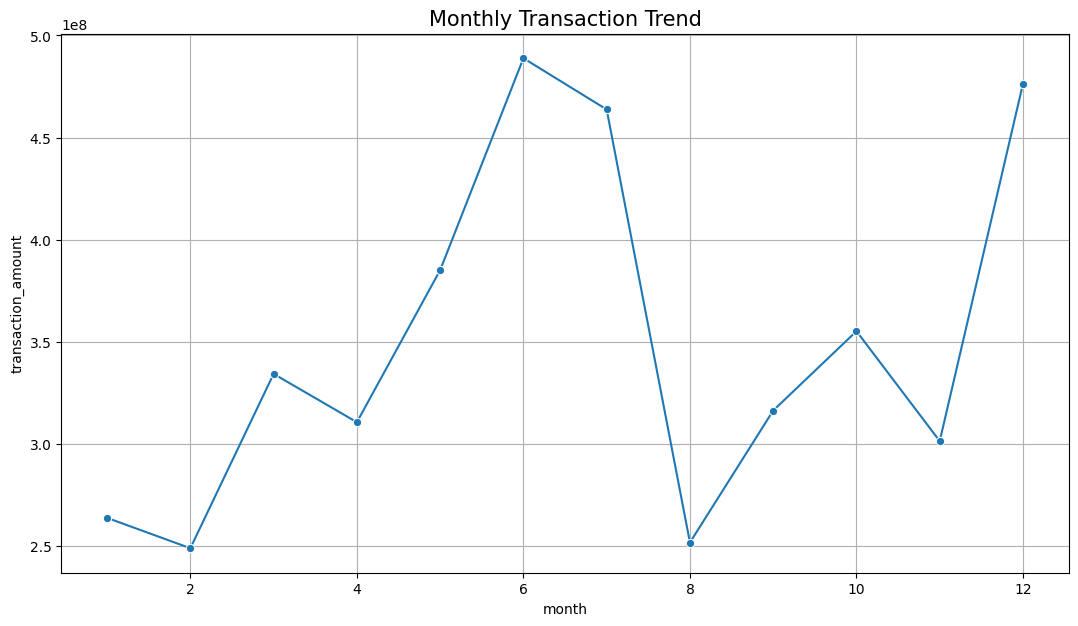

In [10]:
from datetime import datetime
df['check_date']=pd.to_datetime(df['check_date']) # 날짜 형식으로 변환
df['month']=df['check_date'].dt.month # 월 추출
monthly_spend=df.groupby('month')['transaction_amount'].sum().reset_index()

plt.figure(figsize=(13,7))
sns.lineplot(data=monthly_spend, x='month', y='transaction_amount', marker='o')

plt.title('Monthly Transaction Trend', fontsize=15)
plt.grid(True)
plt.show()

- 극단치(Outlier) 찾기

/var/folders/k2/dfxbrnbd63b_b4f_v4qcm5rr0000gn/T/ipykernel_3132/953017659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deps_spend, x='transaction_amount', y='department_title', palette="Set2")


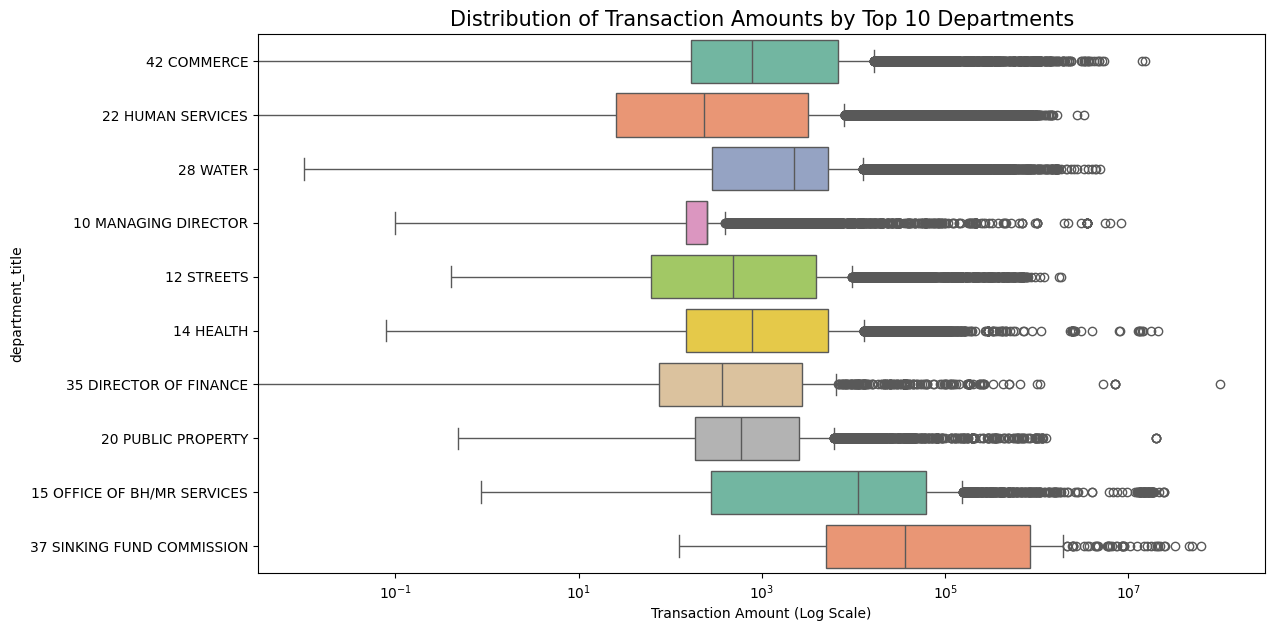

In [11]:
top_deps=df.groupby('department_title')['transaction_amount'].sum().nlargest(10).index
deps_spend=df[df['department_title'].isin(top_deps)]

plt.figure(figsize=(13,7))
sns.boxplot(data=deps_spend, x='transaction_amount', y='department_title', palette="Set2")

plt.xscale('log') # 금액을 로그 스케일로 설정
plt.title('Distribution of Transaction Amounts by Top 10 Departments', fontsize=15)
plt.xlabel('Transaction Amount (Log Scale)')
plt.show()

- 재무국장실(35 DIRECTOR OF FINANCE)의 이상치가 눈에 띈다
- IQR 방식으로 이상치 찾기

In [22]:
def get_outliers(df, column='transaction_amount'):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    upper_bound= Q3 + (1.5*IQR)
    return df[df[column]>upper_bound]
    
target_dept='35 DIRECTOR OF FINANCE'
dept_data=df[df['department_title']==target_dept]
outliers=get_outliers(dept_data)

print(f'{target_dept} 부서의 이상치 거래 수 : {len(outliers)}건')
display(outliers.sort_values(by='transaction_amount', ascending=False).head())

35 DIRECTOR OF FINANCE 부서의 이상치 거래 수 : 184건


,fy,fm,check_date,document_no,dept,department_title,char_,character_title,sub_obj,sub_obj_title,vendor_name,doc_ref_no_prefix,doc_ref_no_prefix_definition,contract_number,contract_description,transaction_amount,month
66116,2017,12,2017-06-16,ACHD17185735,35,35 DIRECTOR OF FINANCE,5,"05 CONTRIBUTIONS,INDEMNITIES,REFDS,TAXES",505,CONTRIBUTIONSED & NONPROF REC ORG 0505,SCHOOL DISTRICT OF PHILADELPHIA,PVXX,payment voucher,NaN,NaN,"99,000,000.00",6
123690,2017,4,2016-10-07,ACHD17047728,35,35 DIRECTOR OF FINANCE,5,"05 CONTRIBUTIONS,INDEMNITIES,REFDS,TAXES",505,CONTRIBUTIONSED & NONPROF REC ORG 0505,COMMUNITY COLLEGE OF PHILADELPHIA,PVMD,professional services,NaN,NaN,"7,227,301.75",10
171727,2017,6,2016-12-16,ACHD17088973,35,35 DIRECTOR OF FINANCE,5,"05 CONTRIBUTIONS,INDEMNITIES,REFDS,TAXES",505,CONTRIBUTIONSED & NONPROF REC ORG 0505,COMMUNITY COLLEGE OF PHILADELPHIA,PVMD,professional services,NaN,NaN,"7,227,301.75",12
226410,2017,9,2017-03-17,ACHD17137125,35,35 DIRECTOR OF FINANCE,5,"05 CONTRIBUTIONS,INDEMNITIES,REFDS,TAXES",505,CONTRIBUTIONSED & NONPROF REC ORG 0505,COMMUNITY COLLEGE OF PHILADELPHIA,PVMD,professional services,NaN,NaN,"7,227,301.75",3
18051,2017,1,2016-07-29,ACHD17014772,35,35 DIRECTOR OF FINANCE,5,"05 CONTRIBUTIONS,INDEMNITIES,REFDS,TAXES",505,CONTRIBUTIONSED & NONPROF REC ORG 0505,COMMUNITY COLLEGE OF PHILADELPHIA,PVMD,professional services,NaN,NaN,"7,227,301.75",7


- 부서별 히트맵 그래프

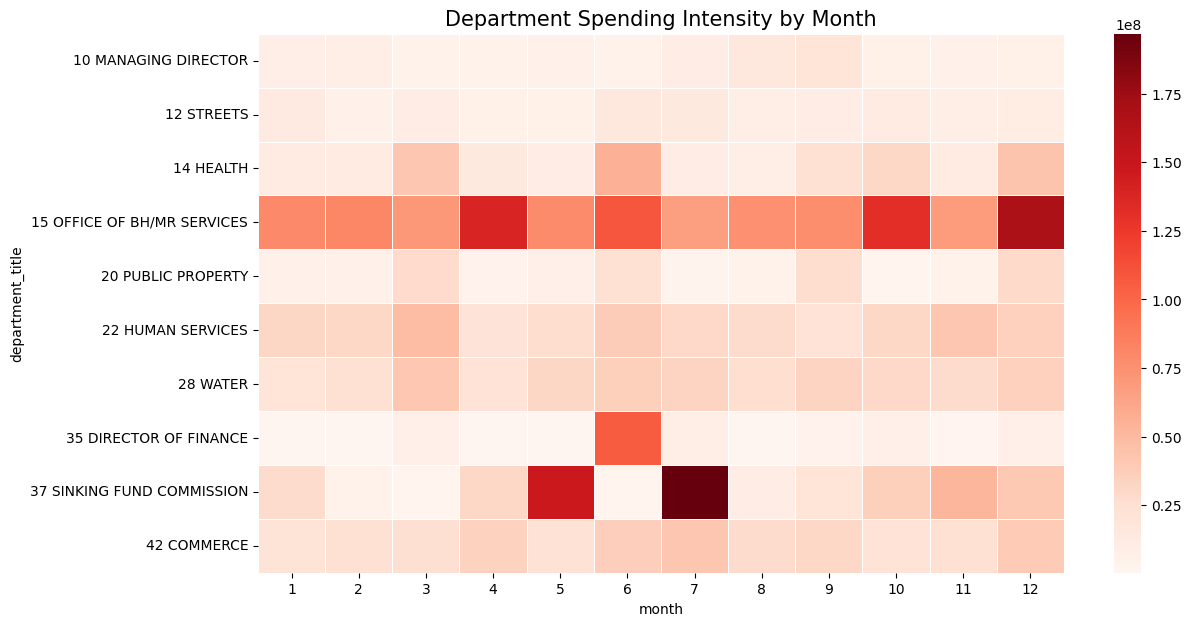

In [13]:
pivot_table=deps_spend.pivot_table(
    index='department_title', 
    columns='month',
    values='transaction_amount',
    aggfunc='sum')

plt.figure(figsize=(13,7))
sns.heatmap(pivot_table, cmap='Reds', linewidth=.5, fmt=',.0f')

plt.title('Department Spending Intensity by Month', fontsize=15)
plt.show()

- 15번 부서(OFFICE OF BH/MR SERVICES) 털어보기

In [18]:
# 돈을 가장 많이 지급한 5개 업체 확인
dept_15 = df[df['department_title'] == '15 OFFICE OF BH/MR SERVICES']
top_vendors = dept_15.groupby('vendor_name')['transaction_amount'].sum().sort_values(ascending=False).head(5)

print("15번 부서 예산 독식 업체 TOP 5:")
display(top_vendors)

# 나머지가 0인 고액 거래(10만 달러 이상) 추출
round_amounts = dept_15[
    (dept_15['transaction_amount'] % 1000 == 0) & 
    (dept_15['transaction_amount'] > 100000)
].sort_values(by='transaction_amount', ascending=False)

print(f"\n1000단위로 딱 떨어지는 고액 의심 거래: {len(round_amounts)}건")
display(round_amounts[['check_date', 'vendor_name', 'sub_obj_title', 'transaction_amount']].head())

15번 부서 예산 독식 업체 TOP 5:


vendor_name
COMMUNITY BEHAVIORAL HEALTH            924,315,742.92
PHILADELPHIA MENTAL HEALTH CARE CORP    39,026,565.79
RESOURCES FOR HUMAN DEVELOPMENT INC     14,748,452.81
PUBLIC HEALTH MANAGEMENT CORP           12,960,476.72
NHS PHILADELPHIA                        11,271,174.49
Name: transaction_amount, dtype: float64


1000단위로 딱 떨어지는 고액 의심 거래: 15건


,check_date,vendor_name,sub_obj_title,transaction_amount
238277,2016-10-28,PHILADELPHIA MENTAL HEALTH CARE CORP,BEHAVORIAL HEALTH AND INTELLECTUAL DISABILITIE...,"1,500,000.00"
238291,2016-10-28,MENTAL HEALTH PARTNERSHIPS INC,BEHAVORIAL HEALTH AND INTELLECTUAL DISABILITIE...,"1,000,000.00"
491,2016-10-28,PHILADELPHIA MENTAL HEALTH CARE CORP,PROFESSIONAL CONSULT/SPEC SERVICES 0250,"735,000.00"
237751,2017-04-07,MENTAL HEALTH PARTNERSHIPS INC,BEHAVORIAL HEALTH AND INTELLECTUAL DISABILITIE...,"500,000.00"
238288,2016-10-28,HORIZON HOUSE INCORPORATED,BEHAVORIAL HEALTH AND INTELLECTUAL DISABILITIE...,"500,000.00"


## 4. Data Preprocessing

In [46]:
# display(df)
features=['fm','dept','char_','sub_obj','vendor_name','transaction_amount']
df_ae=df[features].copy()
display(df_ae)

# 범주형 데이터 변환
cat_cols=['fm','dept','char_','sub_obj']
for col in cat_cols:
    df_ae[col]=df_ae[col].astype(str)

,fm,dept,char_,sub_obj,vendor_name,transaction_amount
0,10,42,2,231,EAT AT JOE'S,66.82
1,12,26,2,211,L & I Â TRAVEL IMPREST FUND,127.33
2,5,44,2,258,"MARLENE BELL REPORTING, INC.",454.20
3,1,11,2,260,RICOH AMERICAS CORPORATION,50.00
4,1,23,3,313,PHILADELPHIA PRISONS,71.92
...,...,...,...,...,...,...
238889,9,15,2,254,DO WHAT YOU'RE BUILT FOR,"52,901.00"
238890,9,15,2,254,SAGE COMMUNICATIONS PARTNERS,"6,675.00"
238891,9,15,2,254,EPIC DEVELOPMENTAL SERVICES,"1,111.60"
238892,9,15,2,254,EPIC DEVELOPMENTAL SERVICES,"28,295.13"


In [47]:
print(f"거래처 수(바꾸기 전): {df_ae['vendor_name'].nunique()}개")
top_50_vendors=df_ae['vendor_name'].value_counts().head(50).index
df_ae.loc[~df_ae['vendor_name'].isin(top_50_vendors),'vendor_name']='ETC'
print(f"거래처 수: {df_ae['vendor_name'].nunique()}개")

거래처 수(바꾸기 전): 5506개
거래처 수: 51개


In [54]:
# 원핫 인코딩
print(df_ae.isnull().sum())
df_encoded=pd.get_dummies(df_ae, columns=['fm','dept','char_','sub_obj','vendor_name'])
display(df_encoded.head())

fm                    0
dept                  0
char_                 0
sub_obj               0
vendor_name           0
transaction_amount    0
dtype: int64


,transaction_amount,fm_1,fm_10,fm_11,fm_12,fm_2,fm_3,fm_4,fm_5,fm_6,...,vendor_name_REVENUE DEPARTMENT,vendor_name_RICOH AMERICAS CORPORATION,vendor_name_STAPLES BUSINESS ADVANTAGE,"vendor_name_STREHLOW & ASSOCIATES, INC.",vendor_name_T D P S MATERIALS,vendor_name_TRANSTECK INC,vendor_name_TRI COUNTY TERMITE & PEST CONTROL INC,vendor_name_UNITED PARCEL SERVICE INC,vendor_name_WINNER FORD,vendor_name_XEROX CORPORATION
0,66.82,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,127.33,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,454.20,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,50.00,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,71.92,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [55]:
# 스케일링
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
df_encoded['transaction_amount']=scaler.fit_transform(df_encoded[['transaction_amount']])
display(df_encoded['transaction_amount'].describe())

count   238,894.00
mean         14.88
std         375.10
min         -70.88
25%          -0.16
50%           0.00
75%           0.84
max      85,057.18
Name: transaction_amount, dtype: float64